# EDA — MagnaTagATune, GTZAN, DEAM

Exploratory analysis of the three datasets used in this project, matching the
requirements of Section 3 of the project spec (dataset characteristics, tag
distribution, class balance, and a sanity check on the audio/graph pipeline).

In [1]:
import sys, os
sys.path.append('..')
from src.utils import load_config
from src.dataset import load_magnatagatune, load_gtzan, load_deam

cfg = load_config('../config.yaml')

## 1. MagnaTagATune — top-50 tag distribution

clips: 21111, tags: 50


<Axes: title={'center': 'MagnaTagATune top-50 tag frequency'}>

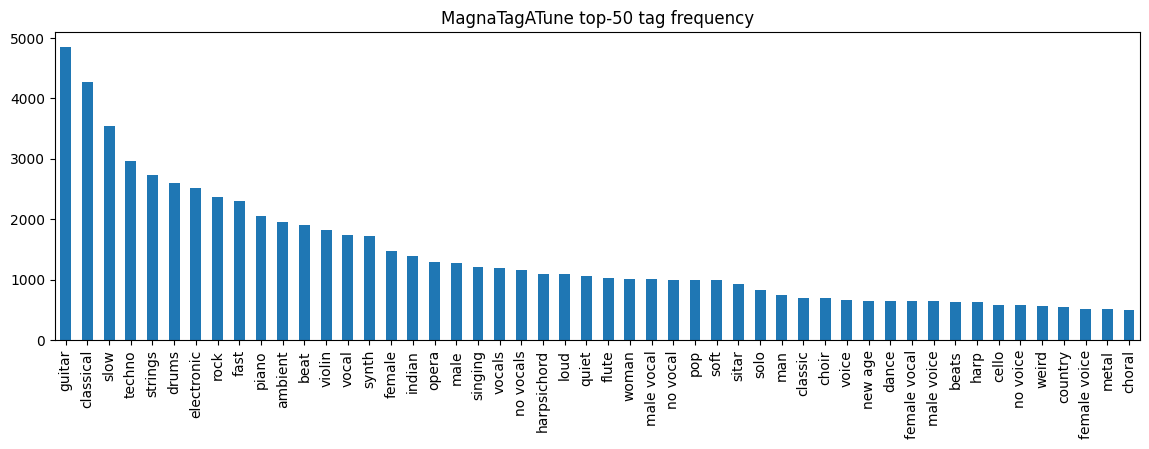

In [2]:
mtt = load_magnatagatune(cfg)
tag_vocab = mtt.attrs['tag_vocab']
print(f"clips: {len(mtt)}, tags: {len(tag_vocab)}")
mtt[tag_vocab].sum().sort_values(ascending=False).plot(kind='bar', figsize=(14, 4), title='MagnaTagATune top-50 tag frequency')

## 2. GTZAN — genre balance

clips: 1000


<Axes: title={'center': 'GTZAN genre counts'}, xlabel='genre'>

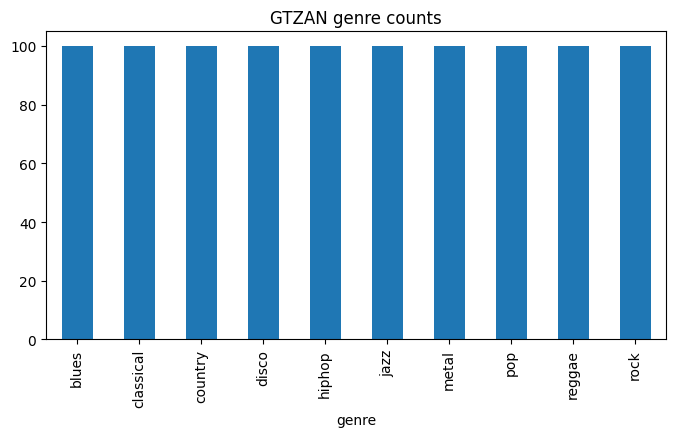

In [3]:
gtzan = load_gtzan(cfg)
print(f"clips: {len(gtzan)}")
gtzan['genre'].value_counts().plot(kind='bar', figsize=(8, 4), title='GTZAN genre counts')

## 3. DEAM — valence/arousal distribution

clips: 1802


Text(0.5, 1.0, 'DEAM valence-arousal scatter')

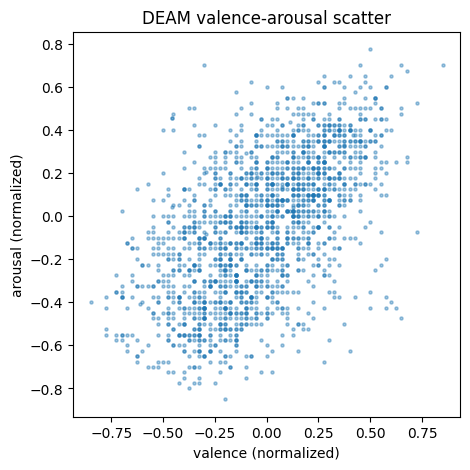

In [4]:
deam = load_deam(cfg)
print(f"clips: {len(deam)}")
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(deam['valence_norm'], deam['arousal_norm'], s=5, alpha=0.4)
ax.set_xlabel('valence (normalized)'); ax.set_ylabel('arousal (normalized)')
ax.set_title('DEAM valence-arousal scatter')

## 4. Sanity check: one audio -> mel/chroma -> segment graph

In [5]:
from src.audio_features import process_clip
from src.graph_builder import build_segment_graph, build_chord_transition_graph

sample_path = gtzan.iloc[0]['path']
feats = process_clip(sample_path, cfg)
print('mel shape:', feats['mel'].shape, 'chroma shape:', feats['chroma'].shape)
print('num segments:', len(feats['segment_bounds']))
print('chord sequence (first 10):', feats['segment_chords'][:10])

seg_graph = build_segment_graph(feats['segment_features'], cfg['graph']['segment_similarity_threshold'])
chord_graph = build_chord_transition_graph(feats['segment_chords'], cfg['graph']['chord_vocab'])
print('segment graph:', seg_graph)
print('chord graph:', chord_graph)

mel shape: (128, 1293) chroma shape: (12, 1293)
num segments: 7
chord sequence (first 10): ['C', 'N', 'N', 'G', 'N', 'N', 'F']


/Users/sifatshariar/Downloads/gnn-bert-music-context/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


segment graph: Data(x=[7, 140], edge_index=[2, 42], edge_attr=[42, 1])
chord graph: Data(x=[25, 26], edge_index=[2, 5], edge_attr=[5, 1])
